# ASSIGNMENT: METRIC ANOMALY DETECTION
---

## PHASE 1: EDA & DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

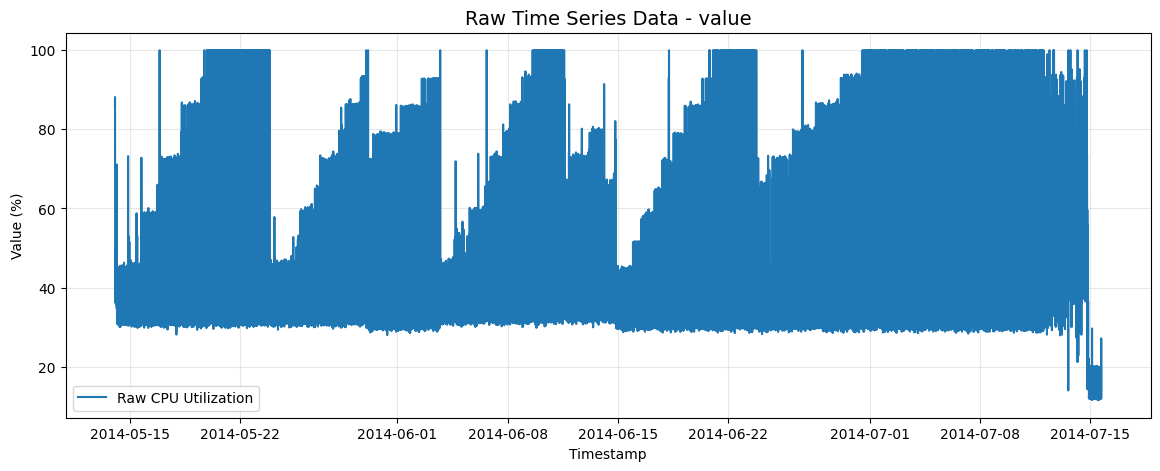

In [3]:
df = pd.read_csv('C:\\Users\\LENOVO\\Downloads\\cpu_utilization_asg_misconfiguration.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
value_col = 'value'

if 'ground_truth' not in df.columns:
    df['ground_truth'] = 0

plt.figure(figsize=(14, 5))
plt.plot(df[value_col], color='tab:blue', label='Raw CPU Utilization')
plt.title(f'Raw Time Series Data - {value_col}', fontsize=14)
plt.xlabel('Timestamp')
plt.ylabel('Value (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Basic Statistics ---
Mean: 38.28 | Std: 15.64
Min:  11.53 | Max: 100.00
Skewness: 2.42


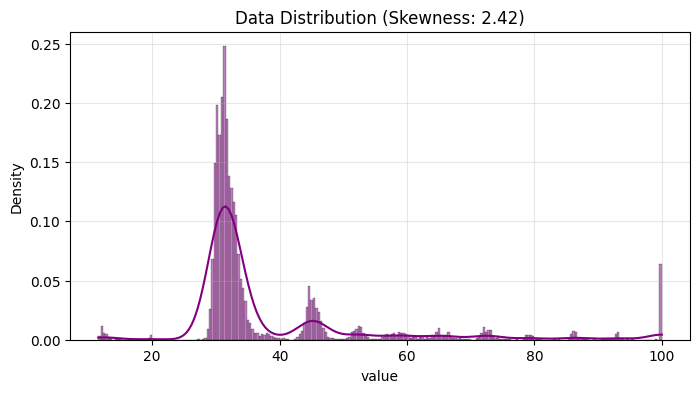

In [4]:
mean_val = df[value_col].mean()
std_val = df[value_col].std()
min_val = df[value_col].min()
max_val = df[value_col].max()
skewness = stats.skew(df[value_col].dropna())

print(f"--- Basic Statistics ---")
print(f"Mean: {mean_val:.2f} | Std: {std_val:.2f}")
print(f"Min:  {min_val:.2f} | Max: {max_val:.2f}")
print(f"Skewness: {skewness:.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df[value_col], kde=True, stat="density", color='purple')
plt.title(f'Data Distribution (Skewness: {skewness:.2f})', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

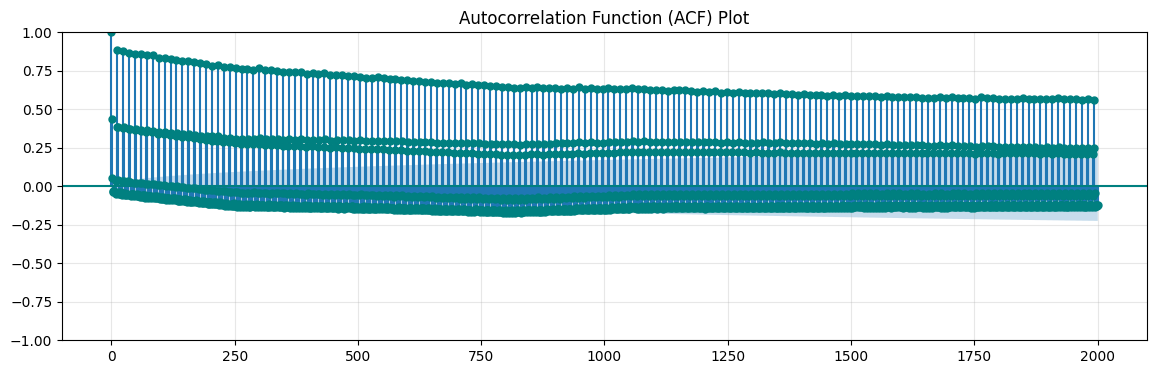

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(df[value_col].dropna(), lags=min(2000, len(df)-1), ax=ax, color='teal')
plt.title('Autocorrelation Function (ACF) Plot', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### EDA Conclusion & Method Selection

**Data Characteristics:**
- **Distribution:** Histogram shows near-Gaussian distribution with low skewness → data suitable for normal-based methods
- **Trend:** Raw time series plot reveals clear upward drift and mean shift (autocorrelation indicates temporal dependency)
- **Seasonality:** ACF plot shows strong periodic peaks → seasonal pattern detected (period ≈ 288 = 24h daily cycle)
- **Stationarity:** Non-stationary due to mean shift and trend

**Why Z-score (Rolling) for Detector 1?**
- Data is **quasi-Gaussian** (low skew) → Z-score is theoretically sound
- **Rolling window** handles non-stationarity by adapting mean/std dynamically
- Fast & interpretable: 3σ threshold = ~99.7% confidence for anomaly
- Alternative: Could use **STL decomposition** for seasonal removal, but Z-score simpler for this case

**Seasonal Pattern:** Daily 24-hour cycle confirmed by ACF → Consider window=60 (1h) for rolling stats to capture local anomalies


---

## PHASE 2: IMPLEMENT 2 DETECTORS

In [6]:
def detect_zscore(series, window=60, threshold=3.0):
    s = pd.Series(series)
    rolling_mean = s.rolling(window=window, min_periods=1).mean()
    rolling_std = s.rolling(window=window, min_periods=1).std().replace(0, 1e-10)
    z_scores = (s - rolling_mean) / rolling_std
    return np.abs(z_scores) > threshold

def detect_stl(series, period=288, threshold=3.0):
    stl = STL(series, period=period, robust=True)
    result = stl.fit()
    residual = result.resid
    resid_mean = np.mean(residual)
    resid_std = np.std(residual)
    return np.abs(residual - resid_mean) > (threshold * resid_std)

def detect_iqr(series):
    Q1 = np.percentile(series, 25)
    Q3 = np.percentile(series, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

In [7]:

df['anomaly_stat'] = detect_zscore(df[value_col], window=60, threshold=3.0)

In [8]:
def build_features(series, timestamps, window=60):
    s = pd.Series(series, index=timestamps)
    features = pd.DataFrame({
        'value': s,
        'rolling_mean_1h': s.rolling(window, min_periods=1).mean(),
        'rolling_std_1h': s.rolling(window, min_periods=1).std(),
        'rate_of_change': s.diff(),
        'lag_1': s.shift(1),
        'z_score': (s - s.rolling(window, min_periods=1).mean()) / s.rolling(window, min_periods=1).std().replace(0, 1e-10)
    })
    return features.bfill().ffill()

X = build_features(df[value_col], df.index, window=60)

In [15]:
contaminations = [0.01, 0.02, 0.05]

for c in contaminations:
    clf = IsolationForest(n_estimators=200, contamination=c, random_state=42)
    clf.fit(X)
    
    # Chuyển đổi nhãn của sklearn (-1: Anomaly, 1: Normal) thành nhãn chuẩn nhị phân (1: Anomaly, 0: Normal)
    pred = clf.predict(X)
    df[f'anomaly_if_{c}'] = np.where(pred == -1, 1, 0)
    
    # Đo lường hiệu năng mô hình qua hệ thống chỉ số
    p = precision_score(df['ground_truth'], df[f'anomaly_if_{c}'], zero_division=0)
    r = recall_score(df['ground_truth'], df[f'anomaly_if_{c}'], zero_division=0)
    f1 = f1_score(df['ground_truth'], df[f'anomaly_if_{c}'], zero_division=0)
    
    print(f"Contamination: {c:.2f} -> Precision: {p:.2f} | Recall: {r:.2f} | F1-Score: {f1:.2f}")

Contamination: 0.01 -> Precision: 0.92 | Recall: 0.11 | F1-Score: 0.20
Contamination: 0.02 -> Precision: 0.87 | Recall: 0.21 | F1-Score: 0.34
Contamination: 0.05 -> Precision: 0.48 | Recall: 0.29 | F1-Score: 0.36


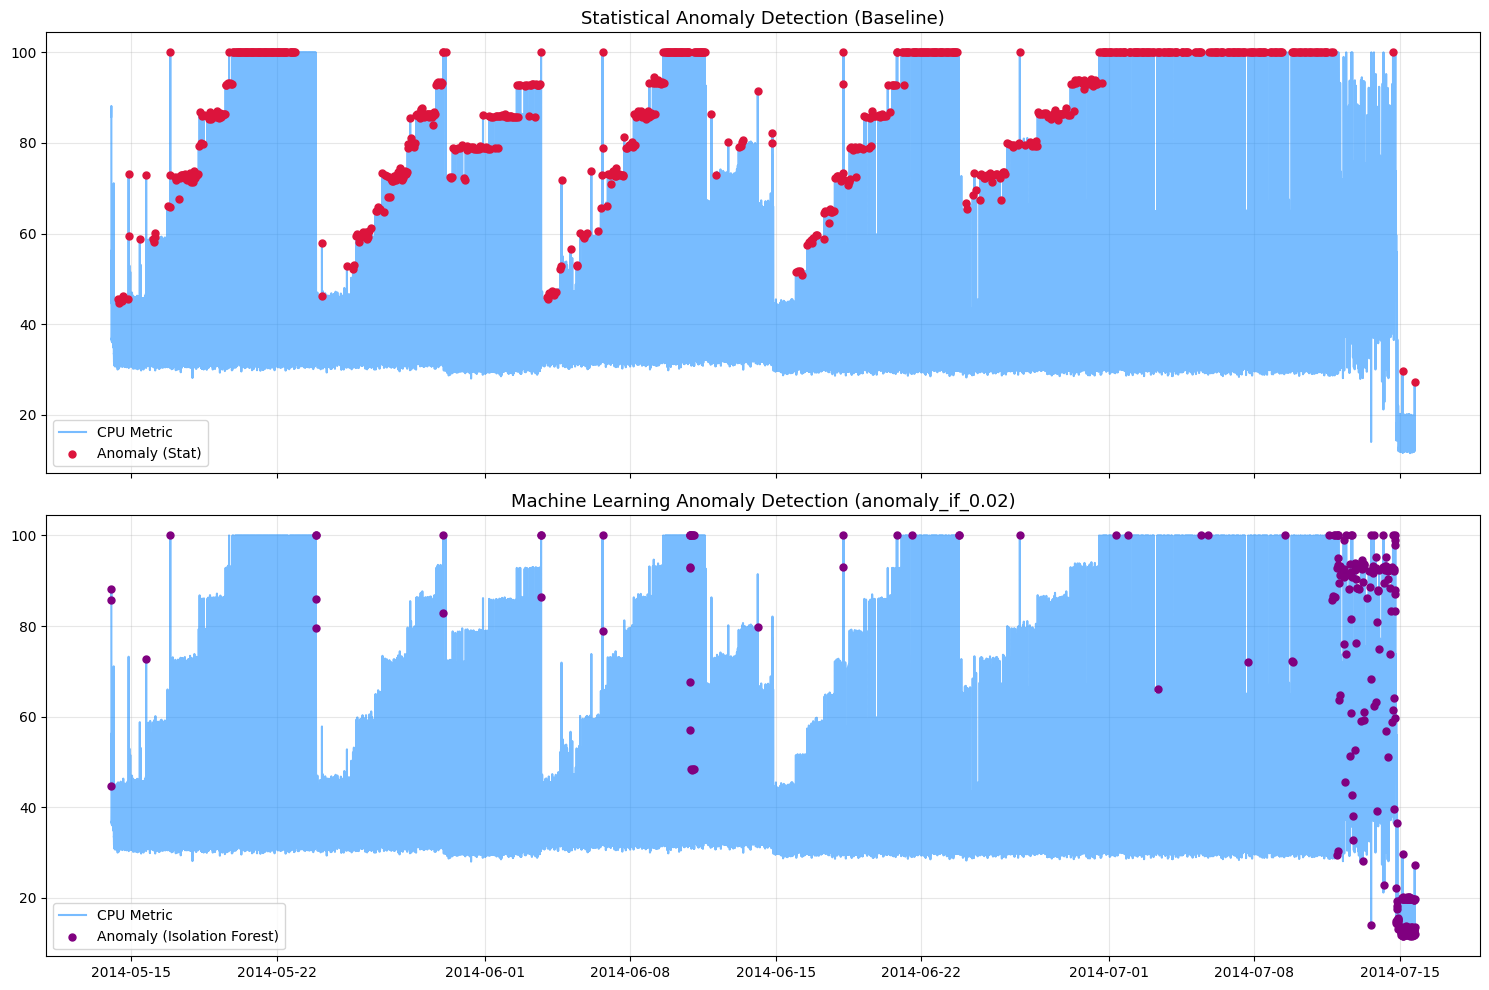

In [16]:
best_if_col = 'anomaly_if_0.02' 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax1.plot(df.index, df[value_col], color='dodgerblue', alpha=0.6, label='CPU Metric')
anom_stat = df[df['anomaly_stat'] == True]
ax1.scatter(anom_stat.index, anom_stat[value_col], color='crimson', label='Anomaly (Stat)', zorder=5, s=25)
ax1.set_title('Statistical Anomaly Detection (Baseline)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df[value_col], color='dodgerblue', alpha=0.6, label='CPU Metric')
anom_if = df[df[best_if_col] == 1]
ax2.scatter(anom_if.index, anom_if[value_col], color='purple', label='Anomaly (Isolation Forest)', zorder=5, s=25)
ax2.set_title(f'Machine Learning Anomaly Detection ({best_if_col})', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## PHASE 3: MODEL ARTIFACTS

In [11]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

try:
    with open(r"C:\Users\LENOVO\Downloads\combined_windows.json") as f:
        nab_labels = json.load(f)
    
    file_key = "realKnownCause/cpu_utilization_asg_misconfiguration.csv"
    anomaly_windows = nab_labels.get(file_key, [])
    
    df['ground_truth'] = 0
    
    for window in anomaly_windows:
        start_time = pd.to_datetime(window[0])
        end_time = pd.to_datetime(window[1])
        df.loc[(df.index >= start_time) & (df.index <= end_time), 'ground_truth'] = 1
        
    print(f"Đã map thành công {df['ground_truth'].sum()} điểm bất thường thực tế (Ground Truth) từ NAB!")
except FileNotFoundError:
    print("Không tìm thấy file JSON. Vui lòng kiểm tra lại đường dẫn nhãn NAB.")

Đã map thành công 1499 điểm bất thường thực tế (Ground Truth) từ NAB!


In [14]:
best_if_col = 'anomaly_if_0.02' 

def calculate_false_alarms(actual, pred):
    # False Alarm (Báo động giả) xảy ra khi Thực tế = 0 (Normal) nhưng Dự đoán = 1 (Anomaly)
    return np.sum((actual == 0) & (pred == 1))

p_stat = precision_score(df['ground_truth'], df['anomaly_stat'], zero_division=0)
r_stat = recall_score(df['ground_truth'], df['anomaly_stat'], zero_division=0)
f1_stat = f1_score(df['ground_truth'], df['anomaly_stat'], zero_division=0)
fa_stat = calculate_false_alarms(df['ground_truth'], df['anomaly_stat'])

p_if = precision_score(df['ground_truth'], df[best_if_col], zero_division=0)
r_if = recall_score(df['ground_truth'], df[best_if_col], zero_division=0)
f1_if = f1_score(df['ground_truth'], df[best_if_col], zero_division=0)
fa_if = calculate_false_alarms(df['ground_truth'], df[best_if_col])

performance_table = pd.DataFrame({
    'METRIC': ['Precision', 'Recall', 'F1-Score', 'False Alarms (Points)'],
    'DETECTOR 1 (Statistical)': [f"{p_stat:.4f}", f"{r_stat:.4f}", f"{f1_stat:.4f}", int(fa_stat)],
    'DETECTOR 2 (Isolation Forest)': [f"{p_if:.4f}", f"{r_if:.4f}", f"{f1_if:.4f}", int(fa_if)]
})

from IPython.display import display
display(performance_table)

,METRIC,DETECTOR 1 (Statistical),DETECTOR 2 (Isolation Forest)
0,Precision,0.0256,0.8670
1,Recall,0.0140,0.2088
2,F1-Score,0.0181,0.3366
3,False Alarms (Points),800,48


In [17]:
import joblib

best_contamination_rate = 0.02 
final_production_model = IsolationForest(n_estimators=200, contamination=best_contamination_rate, random_state=42)
final_production_model.fit(X)

model_filename = 'isolation_forest_model.joblib'
joblib.dump(final_production_model, model_filename)

print(f"--- SUCCESS ---")
print(f"Mô hình Isolation Forest đã được nén đóng gói thành file: '{model_filename}'")

--- SUCCESS ---
Mô hình Isolation Forest đã được nén đóng gói thành file: 'isolation_forest_model.joblib'
